## Task 1: Data Preparation
1. Description:
In this task, you will be responsible for loading
the dataset and conducting an initial
exploration. Handle missing values, and if
necessary, convert categorical variables into
numerical representations. Furthermore, split
the dataset into training and testing sets for
subsequent model evaluation.
2. skill :  
Data loading, data exploration,
Handling missing values,
Data preprocessing,
Categorical variable encoding,
Dataset splitting.


## Task 1: Data Preparation

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [4]:
df = pd.read_csv("Telco_Customer_Churn_Dataset  (3).csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
print(df.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe() 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum() 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [12]:
import numpy as np

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df = df.dropna()

In [13]:
df.shape

(7032, 21)

In [14]:
import numpy as np

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)              #Mean/Median se fill karo

C:\Users\visha\AppData\Local\Temp\ipykernel_21744\893653406.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)              #Mean/Median se fill karo


In [15]:
df["Churn"] = df["Churn"].map({"No":0,"Yes":1})

In [16]:
df['Churn']

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [17]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
# 2. Duplicate rows check 

df.duplicated().sum()

np.int64(0)

In [ ]:
# 3. customerID check 

df.drop('customerID', axis=1, inplace=True) 

In [21]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
#These need to be turned into numerical problems:
df = pd.get_dummies(df, drop_first=True)

In [23]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [24]:
x = df.drop("Churn", axis=1)
y = df["Churn"]

In [25]:
x

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


In [26]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [27]:
print(x.shape)

(7032, 30)


In [28]:
print(y.shape)

(7032,)


In [29]:
(df.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Encoding

In [30]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender_Male"] = le.fit_transform(df["gender_Male"])

In [31]:
df["gender_Male"]

0       0
1       1
2       1
3       1
4       0
       ..
7038    1
7039    0
7040    0
7041    1
7042    1
Name: gender_Male, Length: 7032, dtype: int64

In [33]:
print(df.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [34]:
x = df.drop("Churn", axis=1)
y = df["Churn"]

In [35]:
x

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,1,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,1,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,0,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,1,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


### Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)


In [39]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

## Task 2: Exploratory Data Analysis (EDA) 
1. Description:
Calculate and visually represent the overall
churn rate. Explore customer distribution by
gender, partner status, and dependent status.
Analyze tenure distribution and its relation
with churn. Investigate how churn varies
across different contract types and payment
methods.

2. skills :  
Data visualization, statistical analysis,
Exploratory data analysis,
Understanding of customer demographic,
variables,
Churn rate calculation,



In [40]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 0.00%


In [41]:
df["Churn"].mean()

np.float64(0.26578498293515357)

In [42]:
print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


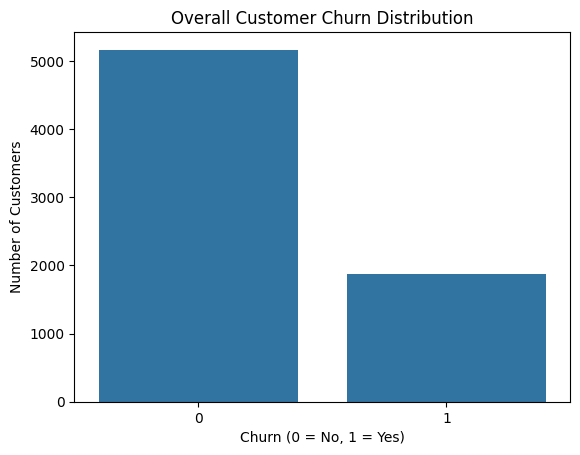

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)

plt.title("Overall Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

##  Customer Distribution by Gender

In [44]:
print(df["gender_Male"].value_counts())

gender_Male
1    3549
0    3483
Name: count, dtype: int64


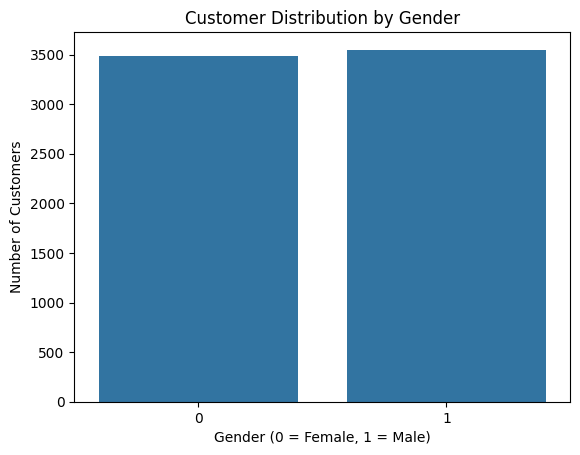

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="gender_Male", data=df)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Number of Customers")
plt.show()

Visualization

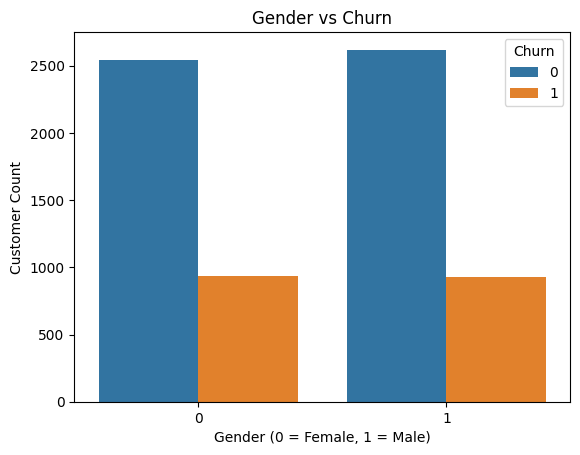

In [46]:
sns.countplot(x="gender_Male", hue="Churn", data=df)

plt.title("Gender vs Churn")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Customer Count")
plt.show()

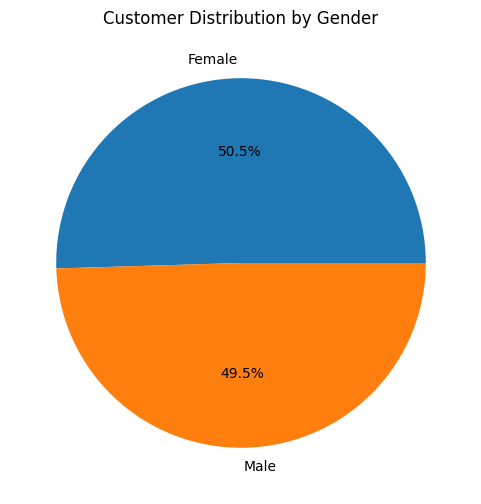

In [47]:
gender_counts = df["gender_Male"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=["Female", "Male"],
    autopct="%1.1f%%"
)

plt.title("Customer Distribution by Gender")
plt.show()

Churn Percentage

In [48]:
gender_churn = pd.crosstab(
    df["gender_Male"],
    df["Churn"],
    normalize="index"
) * 100

print(gender_churn)

Churn                0          1
gender_Male                      
0            73.040482  26.959518
1            73.795435  26.204565


## Customer Distribution by Partner Status

In [49]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,1,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,1,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,1,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,0,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,1,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,0,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,0,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,1,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [50]:
# Count Check
print(df["Partner_Yes"].value_counts())

Partner_Yes
False    3639
True     3393
Name: count, dtype: int64


### visualization

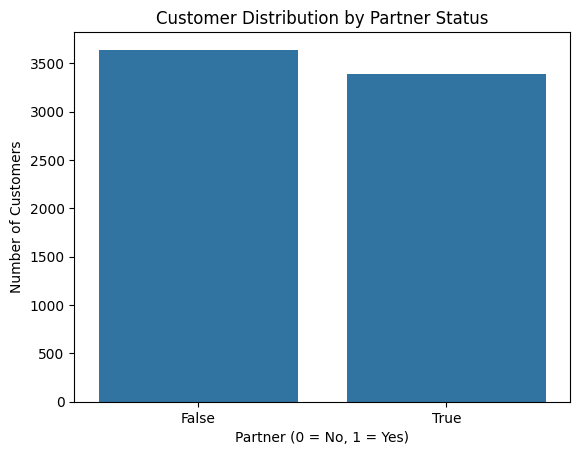

In [51]:
sns.countplot(x="Partner_Yes", data=df)

plt.title("Customer Distribution by Partner Status")
plt.xlabel("Partner (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

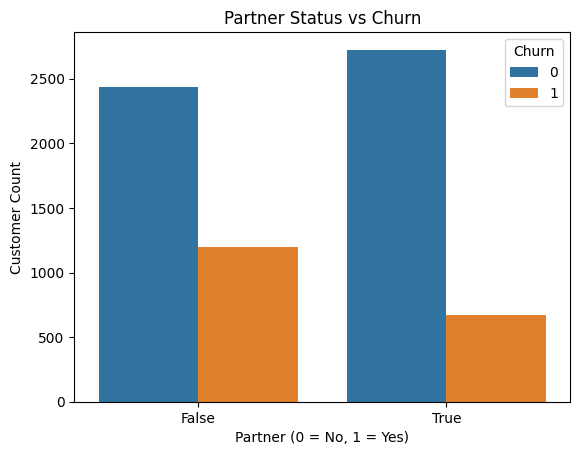

In [52]:
# Partner vs Churn
sns.countplot(x="Partner_Yes", hue="Churn", data=df)

plt.title("Partner Status vs Churn")
plt.xlabel("Partner (0 = No, 1 = Yes)")
plt.ylabel("Customer Count")
plt.show()

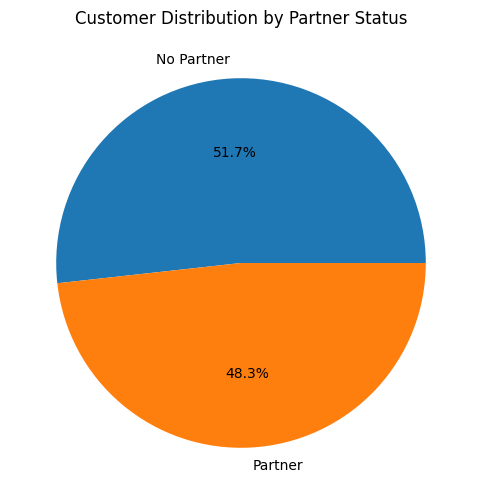

In [53]:
partner_counts = df["Partner_Yes"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    partner_counts,
    labels=["No Partner", "Partner"],
    autopct="%1.1f%%"
)

plt.title("Customer Distribution by Partner Status")
plt.show()

In [54]:
# churn percentage
partner_churn = pd.crosstab(
    df["Partner_Yes"],
    df["Churn"],
    normalize="index"
) * 100

print(partner_churn)

Churn                0          1
Partner_Yes                      
False        67.023908  32.976092
True         80.282935  19.717065


##  Customer Distribution by Dependent Status

In [55]:
# 1 = Has Dependents
# 0 = No Dependents
print(df["Dependents_Yes"].value_counts())


Dependents_Yes
False    4933
True     2099
Name: count, dtype: int64


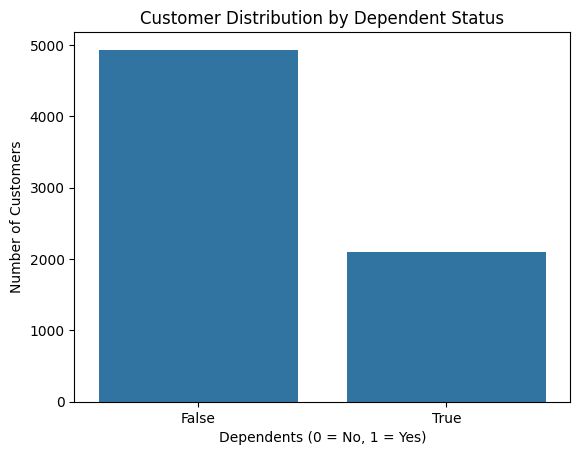

In [56]:
# Visualization

sns.countplot(x="Dependents_Yes", data=df)

plt.title("Customer Distribution by Dependent Status")
plt.xlabel("Dependents (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

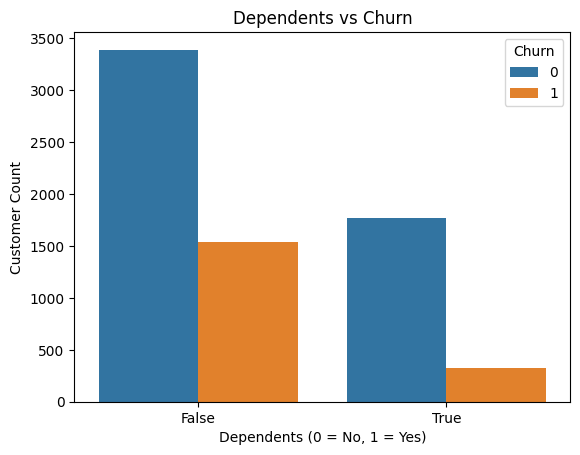

In [57]:
# Dependents vs Churn
sns.countplot(x="Dependents_Yes", hue="Churn", data=df)

plt.title("Dependents vs Churn")
plt.xlabel("Dependents (0 = No, 1 = Yes)")
plt.ylabel("Customer Count")
plt.show()


In [58]:
# Churn Percentage
dependent_churn = pd.crosstab(
    df["Dependents_Yes"],
    df["Churn"],
    normalize="index"
) * 100

print(dependent_churn)

Churn                   0          1
Dependents_Yes                      
False           68.720860  31.279140
True            84.468795  15.531205


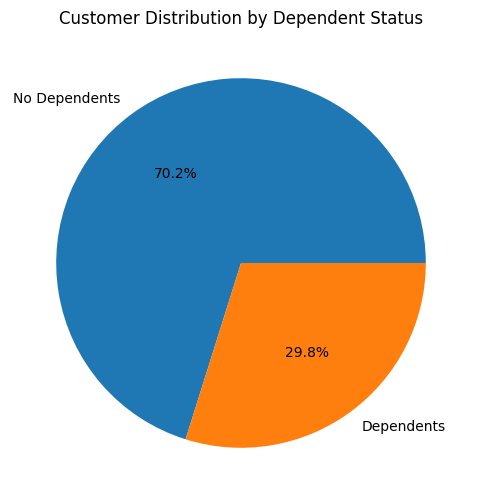

In [59]:
dependent_counts = df["Dependents_Yes"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    dependent_counts,
    labels=["No Dependents", "Dependents"],
    autopct="%1.1f%%"
)

plt.title("Customer Distribution by Dependent Status")
plt.show()

##  Tenure Distribution Check

tenure = Customer kitne months se company ke saath hai.

Example:

1  = 1 month
12 = 1 year
72 = 6 years

In [60]:
print(df["tenure"].describe())

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


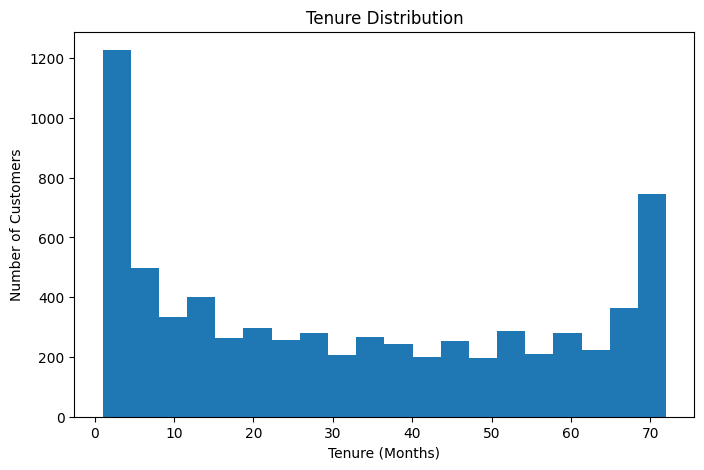

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["tenure"], bins=20)

plt.title("Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

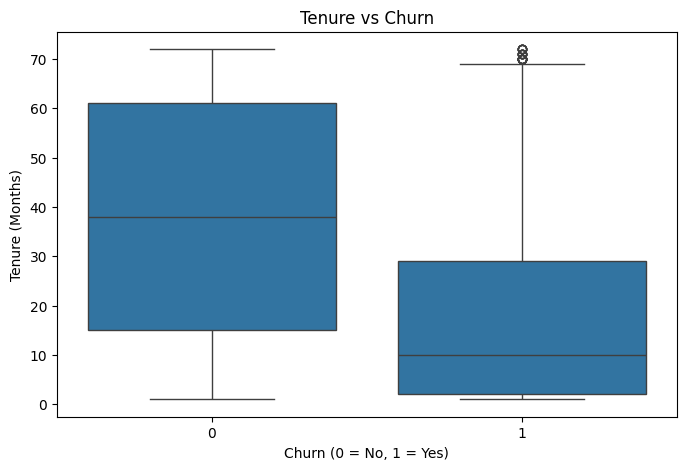

In [62]:
# Tenure vs Churn (Boxplot)

import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (Months)")

plt.show()

Average Tenure by Churn

In [63]:
avg_tenure = df.groupby("Churn")["tenure"].mean()

print(avg_tenure)

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64


In [64]:
df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-12","13-24","25-48","49-72"]
)

churn_by_tenure = pd.crosstab(
    df["Tenure_Group"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_by_tenure)

Churn                 0          1
Tenure_Group                      
0-12          52.321839  47.678161
13-24         71.289062  28.710938
25-48         79.611041  20.388959
49-72         90.486824   9.513176


In [65]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Group
0,0,1,29.85,29.85,0,0,True,False,False,True,...,False,False,False,False,False,True,False,True,False,0-12
1,0,34,56.95,1889.50,0,1,False,False,True,False,...,False,False,False,True,False,False,False,False,True,25-48
2,0,2,53.85,108.15,1,1,False,False,True,False,...,False,False,False,False,False,True,False,False,True,0-12
3,0,45,42.30,1840.75,0,1,False,False,False,True,...,False,False,False,True,False,False,False,False,False,25-48
4,0,2,70.70,151.65,1,0,False,False,True,False,...,False,False,False,False,False,True,False,True,False,0-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,1,True,True,True,False,...,True,False,True,True,False,True,False,False,True,13-24
7039,0,72,103.20,7362.90,0,0,True,True,True,False,...,True,False,True,True,False,True,True,False,False,49-72
7040,0,11,29.60,346.45,0,0,True,True,False,True,...,False,False,False,False,False,True,False,True,False,0-12
7041,1,4,74.40,306.60,1,1,True,False,True,False,...,False,False,False,False,False,True,False,False,True,0-12


Original Contract Type Wapas Banao

Visualization ke liye:

In [66]:
df["Contract_Type"] = "Month-to-month"

df.loc[df["Contract_One year"] == 1, "Contract_Type"] = "One year"

df.loc[df["Contract_Two year"] == 1, "Contract_Type"] = "Two year"

In [67]:
df["Contract_Type"] 

0       Month-to-month
1             One year
2       Month-to-month
3             One year
4       Month-to-month
             ...      
7038          One year
7039          One year
7040    Month-to-month
7041    Month-to-month
7042          Two year
Name: Contract_Type, Length: 7032, dtype: object

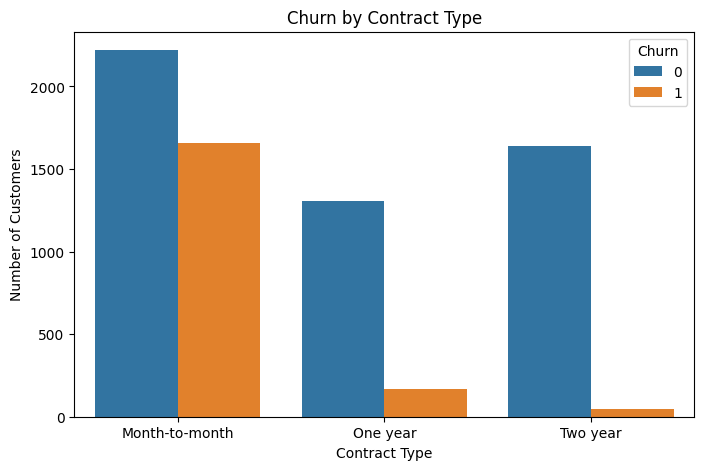

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(x="Contract_Type",hue="Churn",data=df)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [69]:
# Churn Percentage by Contract Type
contract_churn = pd.crosstab(
    df["Contract_Type"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                   0          1
Contract_Type                       
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


Payment Method Column Banao

In [70]:
df["Payment_Method"] = "Bank transfer (automatic)"

df.loc[
    df["PaymentMethod_Credit card (automatic)"] == 1,
    "Payment_Method"
] = "Credit card (automatic)"

df.loc[
    df["PaymentMethod_Electronic check"] == 1,
    "Payment_Method"
] = "Electronic check"

df.loc[
    df["PaymentMethod_Mailed check"] == 1,
    "Payment_Method"
] = "Mailed check"

In [71]:
payment_churn = (
    df.groupby("Payment_Method")["Churn"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

print(payment_churn)

Payment_Method
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64


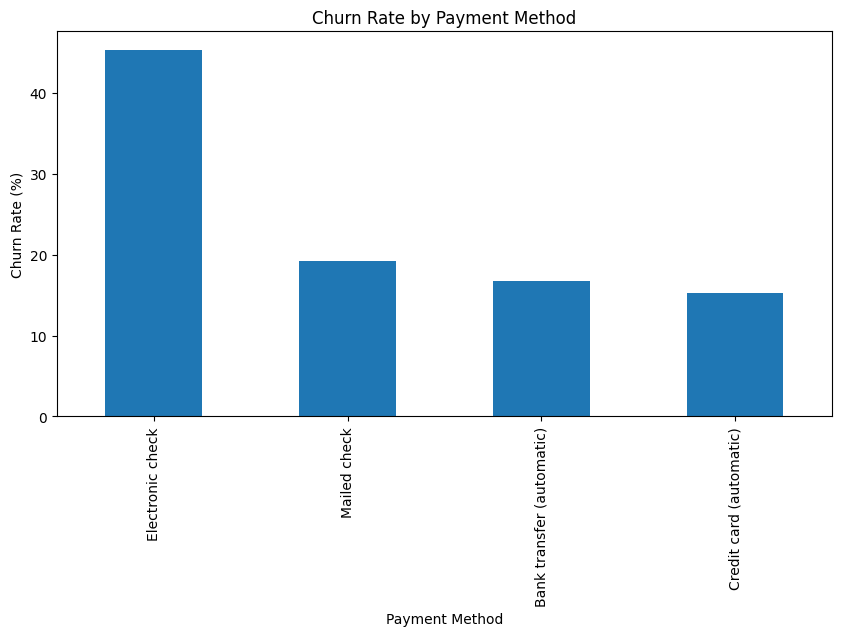

In [72]:
plt.figure(figsize=(10,5))

payment_churn.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.show()

In [73]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Group,Contract_Type,Payment_Method
0,0,1,29.85,29.85,0,0,True,False,False,True,...,False,False,False,True,False,True,False,0-12,Month-to-month,Electronic check
1,0,34,56.95,1889.50,0,1,False,False,True,False,...,False,True,False,False,False,False,True,25-48,One year,Mailed check
2,0,2,53.85,108.15,1,1,False,False,True,False,...,False,False,False,True,False,False,True,0-12,Month-to-month,Mailed check
3,0,45,42.30,1840.75,0,1,False,False,False,True,...,False,True,False,False,False,False,False,25-48,One year,Bank transfer (automatic)
4,0,2,70.70,151.65,1,0,False,False,True,False,...,False,False,False,True,False,True,False,0-12,Month-to-month,Electronic check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,1,True,True,True,False,...,True,True,False,True,False,False,True,13-24,One year,Mailed check
7039,0,72,103.20,7362.90,0,0,True,True,True,False,...,True,True,False,True,True,False,False,49-72,One year,Credit card (automatic)
7040,0,11,29.60,346.45,0,0,True,True,False,True,...,False,False,False,True,False,True,False,0-12,Month-to-month,Electronic check
7041,1,4,74.40,306.60,1,1,True,False,True,False,...,False,False,False,True,False,False,True,0-12,Month-to-month,Mailed check


### Task 3: Customer Segmentation
1. Description:
Segment customers based on tenure,
monthly charges, and contract type. Analyze
churn rates within these segments. Identify
high-value customers who are at risk of
churning and might need special attention
2. skills :  
. Segmentation techniques,
. Understanding of customer behavior,
. Churn analysis within segments,
. Identifying high-value customers

### Segment Customers Based on Tenure 

1. pd.cut() :  numerical data ko categories me divide karta hai.
2. bins : range define karte hain.
3. labels :  har range ka naam dete hain.

In [74]:
df["Tenure_Segment"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "New Customer",
        "Regular Customer",
        "Loyal Customer",
        "Long-Term Customer"
    ]
)

df[["tenure", "Tenure_Segment"]].head()

,tenure,Tenure_Segment
0,1,New Customer
1,34,Loyal Customer
2,2,New Customer
3,45,Loyal Customer
4,2,New Customer


In [75]:
# Har Segment me Kitne Customers Hain
print(df["Tenure_Segment"].value_counts())

Tenure_Segment
Long-Term Customer    2239
New Customer          2175
Loyal Customer        1594
Regular Customer      1024
Name: count, dtype: int64


In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

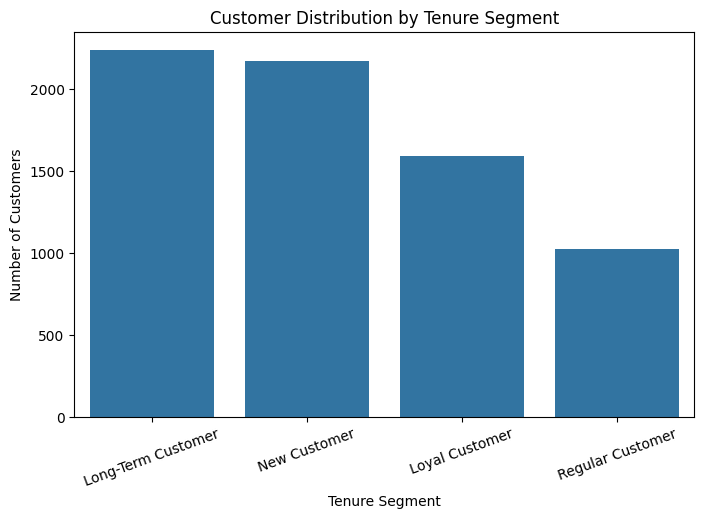

In [77]:
# visualization:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Tenure_Segment",
    data=df,
    order=df["Tenure_Segment"].value_counts().index
)

plt.title("Customer Distribution by Tenure Segment")
plt.xlabel("Tenure Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)
plt.show()

In [78]:
# Churn Rate by Tenure Segment
tenure_churn = (
    df.groupby("Tenure_Segment")["Churn"]
      .mean()
      * 100
)

print(tenure_churn)

Tenure_Segment
New Customer          47.678161
Regular Customer      28.710938
Loyal Customer        20.388959
Long-Term Customer     9.513176
Name: Churn, dtype: float64


C:\Users\visha\AppData\Local\Temp\ipykernel_21744\244765612.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Tenure_Segment")["Churn"]


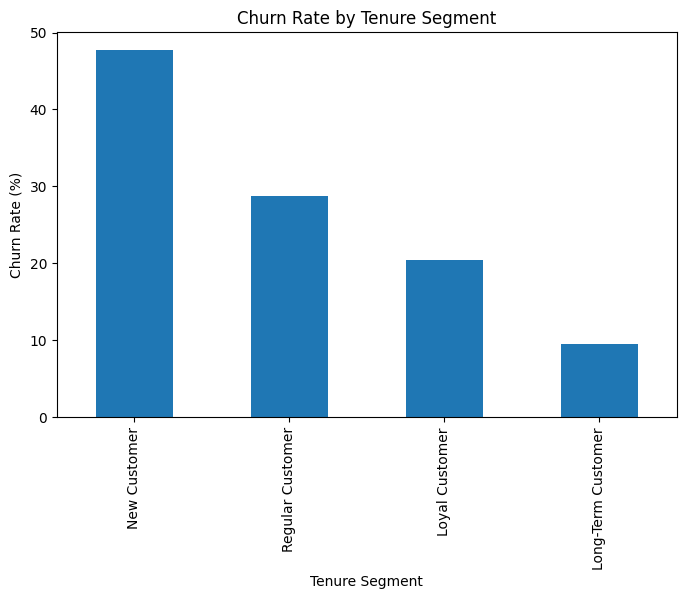

In [79]:
plt.figure(figsize=(8,5))

tenure_churn.plot(kind="bar")
plt.title("Churn Rate by Tenure Segment")
plt.xlabel("Tenure Segment")
plt.ylabel("Churn Rate (%)")

plt.show()

In [80]:
print("Highest Churn Segment:",tenure_churn.idxmax())

print("Highest Churn Rate:",tenure_churn.max())

Highest Churn Segment: New Customer
Highest Churn Rate: 47.67816091954023


###  Segment Customers Based on Monthly Charges

In [81]:
df["MonthlyCharges"]

0        29.85
1        56.95
2        53.85
3        42.30
4        70.70
         ...  
7038     84.80
7039    103.20
7040     29.60
7041     74.40
7042    105.65
Name: MonthlyCharges, Length: 7032, dtype: float64

In [ ]:
# Segments 
df["Charge_Segment"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 35, 70, 120],
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"
    ]
)

In [83]:
df[["MonthlyCharges", "Charge_Segment"]].head()

,MonthlyCharges,Charge_Segment
0,29.85,Low Value
1,56.95,Medium Value
2,53.85,Medium Value
3,42.30,Medium Value
4,70.70,High Value


In [ ]:
# Churn Rate by Charge Segment
# Now, calculate the rate per unit for each segment.

charge_churn = (
    df.groupby("Charge_Segment")["Churn"]
      .mean()
      * 100
)

print(charge_churn)

Charge_Segment
Low Value       10.931174
Medium Value    23.983740
High Value      35.381178
Name: Churn, dtype: float64


C:\Users\visha\AppData\Local\Temp\ipykernel_21744\288407563.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Charge_Segment")["Churn"]


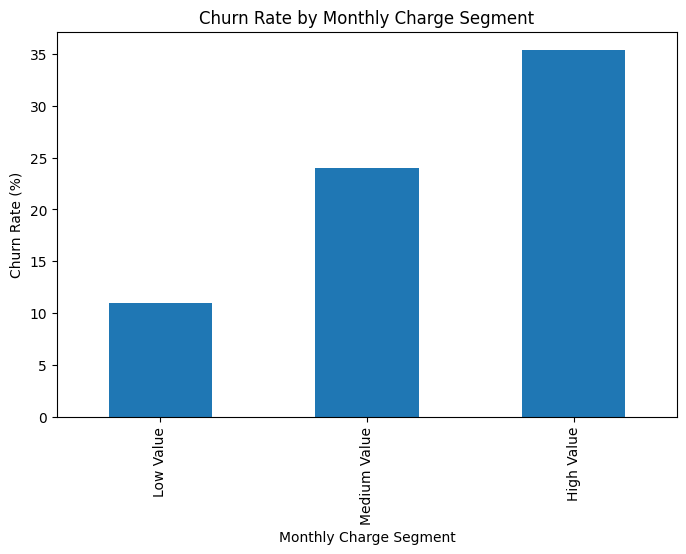

In [85]:
# churn analysis
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

charge_churn.plot(kind="bar")

plt.title("Churn Rate by Monthly Charge Segment")
plt.xlabel("Monthly Charge Segment")
plt.ylabel("Churn Rate (%)")

plt.show()

In [86]:
print("Highest Churn Segment:", charge_churn.idxmax())
print("Churn Rate:", charge_churn.max())

Highest Churn Segment: High Value
Churn Rate: 35.38117844177604


In [87]:
charge_churn.idxmax()

'High Value'

In [88]:
df


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Group,Contract_Type,Payment_Method,Tenure_Segment,Charge_Segment
0,0,1,29.85,29.85,0,0,True,False,False,True,...,False,True,False,True,False,0-12,Month-to-month,Electronic check,New Customer,Low Value
1,0,34,56.95,1889.50,0,1,False,False,True,False,...,False,False,False,False,True,25-48,One year,Mailed check,Loyal Customer,Medium Value
2,0,2,53.85,108.15,1,1,False,False,True,False,...,False,True,False,False,True,0-12,Month-to-month,Mailed check,New Customer,Medium Value
3,0,45,42.30,1840.75,0,1,False,False,False,True,...,False,False,False,False,False,25-48,One year,Bank transfer (automatic),Loyal Customer,Medium Value
4,0,2,70.70,151.65,1,0,False,False,True,False,...,False,True,False,True,False,0-12,Month-to-month,Electronic check,New Customer,High Value
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,1,True,True,True,False,...,False,True,False,False,True,13-24,One year,Mailed check,Regular Customer,High Value
7039,0,72,103.20,7362.90,0,0,True,True,True,False,...,False,True,True,False,False,49-72,One year,Credit card (automatic),Long-Term Customer,High Value
7040,0,11,29.60,346.45,0,0,True,True,False,True,...,False,True,False,True,False,0-12,Month-to-month,Electronic check,New Customer,Low Value
7041,1,4,74.40,306.60,1,1,True,False,True,False,...,False,True,False,False,True,0-12,Month-to-month,Mailed check,New Customer,High Value


### Segment Customers Based on Contract Type

In [ ]:
# Contract types have been recreated.

df["Contract_Type"] = "Month-to-month"

df.loc[df["Contract_One year"] == True, "Contract_Type"] = "One year"

df.loc[df["Contract_Two year"] == True, "Contract_Type"] = "Two year"

In [90]:
df[[
    "Contract_One year",
    "Contract_Two year",
    "Contract_Type"
]].head()

,Contract_One year,Contract_Two year,Contract_Type
0,False,False,Month-to-month
1,True,False,One year
2,False,False,Month-to-month
3,True,False,One year
4,False,False,Month-to-month


In [91]:
# Churn Rate by Contract Type
contract_churn = (
    df.groupby("Contract_Type")["Churn"]
      .mean()
      * 100
)

print(contract_churn)

Contract_Type
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


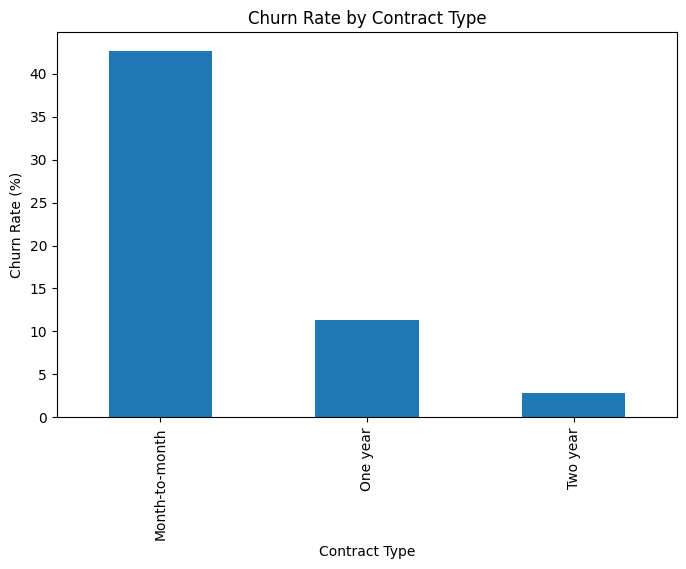

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

In [93]:
print("Highest Churn Segment:", contract_churn.idxmax())
print("Churn Rate:", contract_churn.max())

Highest Churn Segment: Month-to-month
Churn Rate: 42.70967741935484


In [ ]:
# High-Value Customers Identify 
high_value = df[
    (df["MonthlyCharges"] > 70) &
    (df["tenure"] > 24)
]

# Selecting only those customers:
# MonthlyCharges > 70
# tenure > 24 months
print("High Value Customers:", len(high_value))

High Value Customers: 2230


In [ ]:
# Deriving value from high-risk, high-value customers.

at_risk = high_value[
    high_value["Contract_Type"] == "Month-to-month"
]

print("At Risk High Value Customers:", len(at_risk))

At Risk High Value Customers: 811


In [ ]:
#see  Important Customer List 
at_risk[
    [
        "tenure",
        "MonthlyCharges",
        "Contract_Type"
    ]
].head()

,tenure,MonthlyCharges,Contract_Type
8,28,104.80,Month-to-month
13,49,103.70,Month-to-month
14,25,105.50,Month-to-month
26,47,99.35,Month-to-month
37,46,74.80,Month-to-month


In [97]:
# percentage 
risk_percent = (
    len(at_risk) /
    len(high_value)
) * 100

print(f"At-Risk High Value Customers: {risk_percent:.2f}%")

At-Risk High Value Customers: 36.37%


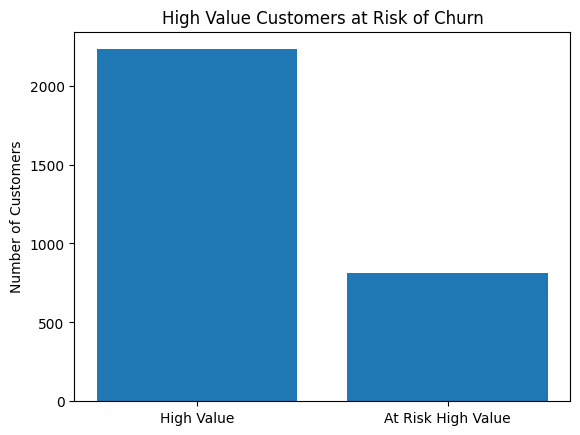

In [98]:
# visualization 
import matplotlib.pyplot as plt

counts = [
    len(high_value),
    len(at_risk)
]

labels = [
    "High Value",
    "At Risk High Value"
]

plt.bar(labels, counts)

plt.title("High Value Customers at Risk of Churn")
plt.ylabel("Number of Customers")

plt.show()

In [99]:
df["Churn"]

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

### Task 4: Churn Prediction Model
1. Description:
Choose suitable machine learning algorithms
(e.g., logistic regression, decision trees) for
churn prediction. Split data into training and
testing sets, train and evaluate multiple
models using metrics like accuracy, precision,
recall, and F1-score. Perform feature selection
and hyperparameter tuning for optimal
performance. 

2. Skills :

2. Machine learning algorithms
2. Model training and evaluation,
2. Feature selection, hyperparameter tuning
2. Understanding of classification metrics

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [101]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [102]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
X = df.drop("Churn", axis=1) # X = Input Features
x

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,1,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,1,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,0,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,1,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


In [104]:
y = df["Churn"]  #y = Target
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [105]:
print(X_train.shape)
print(X_test.shape)

(5625, 35)
(1407, 35)


In [106]:
from sklearn.linear_model import LogisticRegression

In [107]:
print(X.dtypes[X.dtypes == "object"])

Contract_Type     object
Payment_Method    object
dtype: object


In [108]:
X.select_dtypes(include="object").columns

Index(['Contract_Type', 'Payment_Method'], dtype='object')

In [109]:
print(X.select_dtypes(include=["object","category"]).columns)

Index(['Tenure_Group', 'Contract_Type', 'Payment_Method', 'Tenure_Segment',
       'Charge_Segment'],
      dtype='object')


In [110]:



X = df.drop(
    columns=[
        "Churn",
        "Contract_Type",
        "Payment_Method",
        "Tenure_Group",
        "Tenure_Segment",
        "Charge_Segment"
    ],
    errors="ignore"
)

In [111]:
print(X.select_dtypes(include=["object","category"]).columns)

Index([], dtype='object')


In [112]:
from sklearn.model_selection import train_test_split

y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [113]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)



c:\Users\visha\OneDrive\Desktop\pandas\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_pred_lr = lr.predict(X_test)  #The model will make predictions on the test data.

In [115]:
y_pred_lr

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

In [116]:
print(X.shape)

(7032, 30)


In [117]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)  #Model create hua.

dt.fit(X_train, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [118]:
y_pred_dt = dt.predict(X_test)  # prediction 

In [119]:
y_pred_dt

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

In [120]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [121]:
y_pred_rf

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

In [122]:
lr.fit(X_train, y_train)

dt.fit(X_train, y_train)

c:\Users\visha\OneDrive\Desktop\pandas\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [123]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [124]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [125]:
x

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,1,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,1,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,0,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,1,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


In [126]:
from sklearn.model_selection import train_test_split

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [128]:
x  # feature hai 

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,1,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,1,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,0,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,1,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


In [129]:
y  # target hai 

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [130]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)   # Training labels.

print(y_test.shape)    # Testing labels.

(5625, 35)
(1407, 35)
(5625,)
(1407,)


In [131]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [132]:
print(X_train.select_dtypes(include=["object", "category"]).columns)

Index(['Tenure_Group', 'Contract_Type', 'Payment_Method', 'Tenure_Segment',
       'Charge_Segment'],
      dtype='object')


In [133]:
print(X_train.dtypes[X_train.dtypes == "object"])

Contract_Type     object
Payment_Method    object
dtype: object


In [134]:
X = df.drop(
    columns=[
        "Churn",
        "Contract_Type",
        "Payment_Method",
        "Tenure_Group",
        "Tenure_Segment",
        "Charge_Segment"
    ],
    errors="ignore"
)

In [135]:
X = df.drop(
    columns=[
        "Churn",
        "Contract_Type",
        "Payment_Method",
        "Tenure_Group",
        "Tenure_Segment",
        "Charge_Segment"
    ],
    errors="ignore"
)

y = df["Churn"]

In [136]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [137]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [138]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [139]:
# scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [140]:
X_train_scaled.shape

(5625, 30)

In [141]:
X_test_scaled.shape

(1407, 30)

In [142]:
print(X_train.select_dtypes(include=["object", "category"]).columns)

Index([], dtype='object')


In [143]:
print(X.select_dtypes(include=["object", "category"]).columns)

Index([], dtype='object')


In [144]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [145]:
y_pred_lr = lr.predict(X_test_scaled)   # prediction 

In [146]:
y_pred_lr

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

In [147]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [ ]:
# We are evaluating logistic regression. 

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.7874911158493249
Precision: 0.6205787781350482
Recall   : 0.516042780748663
F1 Score : 0.5635036496350365


In [149]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [150]:
y_pred_dt = dt.predict(X_test)

In [151]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Accuracy : 0.7249466950959488
Precision: 0.4838709677419355
Recall   : 0.5213903743315508
F1 Score : 0.5019305019305019


1. Perform feature selection and hyperparameter tuning for optimal performance

2. Feature Selection work:
Important Features
↓
give model

3. 
✅ Model fast

✅ Overfitting is less

✅ Important factors have changed



In [ ]:
# We are using Random Forest to determine feature importance. 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [153]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [154]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                           Feature  Importance
3                     TotalCharges    0.193409
2                   MonthlyCharges    0.169758
1                           tenure    0.167572
10     InternetService_Fiber optic    0.039999
28  PaymentMethod_Electronic check    0.035016
13              OnlineSecurity_Yes    0.028905
25               Contract_Two year    0.028618
4                      gender_Male    0.026971
19                 TechSupport_Yes    0.025829
26            PaperlessBilling_Yes    0.025044


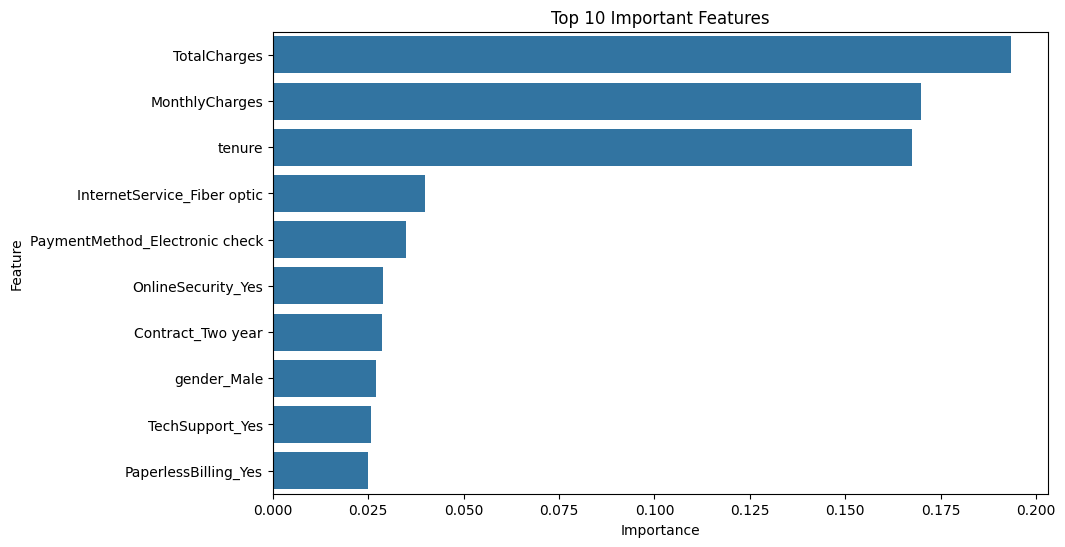

In [ ]:
#  visulization 

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

### Hyperparameter Tuning
1. Example:

How deep should the tree be?
max_depth

In [156]:
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Parameters Define 
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

In [158]:
param_grid

{'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}

In [ ]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,   # 5-fold cross-validation: This will test the model 5 times.
    scoring="f1"
)

In [160]:
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [ ]:
grid.fit(X_train, y_train)   #Grid search will try out combinations and select the best one. 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [162]:
print(grid.best_params_)   # best parameter 

{'max_depth': 5, 'min_samples_split': 2}


In [163]:
print(grid.best_score_)  # best score 

0.5721442958526478


In [164]:
best_dt = grid.best_estimator_    # best model 

In [165]:
best_dt

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [166]:
y_pred_best = best_dt.predict(X_test)

In [167]:
y_pred_best

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

In [168]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

Accuracy : 0.775408670931059
Precision: 0.5755208333333334
Recall   : 0.5909090909090909
F1 Score : 0.58311345646438


In [169]:
print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", grid.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2}
Best F1 Score: 0.5721442958526478


grid.best_estimator_ returns the machine learning model with the best hyperparameters found during GridSearchCV. It is used to make final predictions and evaluate the optimized model.

In [ ]:
best_dt = grid.best_estimator_     #GridSearchCV ne jo best Decision Tree model

In [171]:
y_pred_best = best_dt.predict(X_test)

In [172]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

Accuracy : 0.775408670931059
Precision: 0.5755208333333334
Recall   : 0.5909090909090909
F1 Score : 0.58311345646438


###  Task 5: Model Evaluation and Interpretation
1. Description:
Evaluate the best predictive model using the
testing dataset. Interpret model coefficients or
feature importances to comprehend factors
influencing churn. Create ROC curves and
calculate AUC for model performance
assessment.

2. skills 
3. Model evaluation
4. Interpreting coefficients/features importance
4. ROC curve analysis
4. AUC calculation
4. Understanding of model performance metrics.


In [ ]:

# best model Tuned Decision Tree .
best_dt = grid.best_estimator_

In [174]:
# Prediction Karo
y_pred_best = best_dt.predict(X_test)

In [175]:
y_pred_best

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

In [176]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Evaluation Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

Accuracy : 0.775408670931059
Precision: 0.5755208333333334
Recall   : 0.5909090909090909
F1 Score : 0.58311345646438


In [177]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                           Feature  Importance
3                     TotalCharges    0.193409
2                   MonthlyCharges    0.169758
1                           tenure    0.167572
10     InternetService_Fiber optic    0.039999
28  PaymentMethod_Electronic check    0.035016
13              OnlineSecurity_Yes    0.028905
25               Contract_Two year    0.028618
4                      gender_Male    0.026971
19                 TechSupport_Yes    0.025829
26            PaperlessBilling_Yes    0.025044


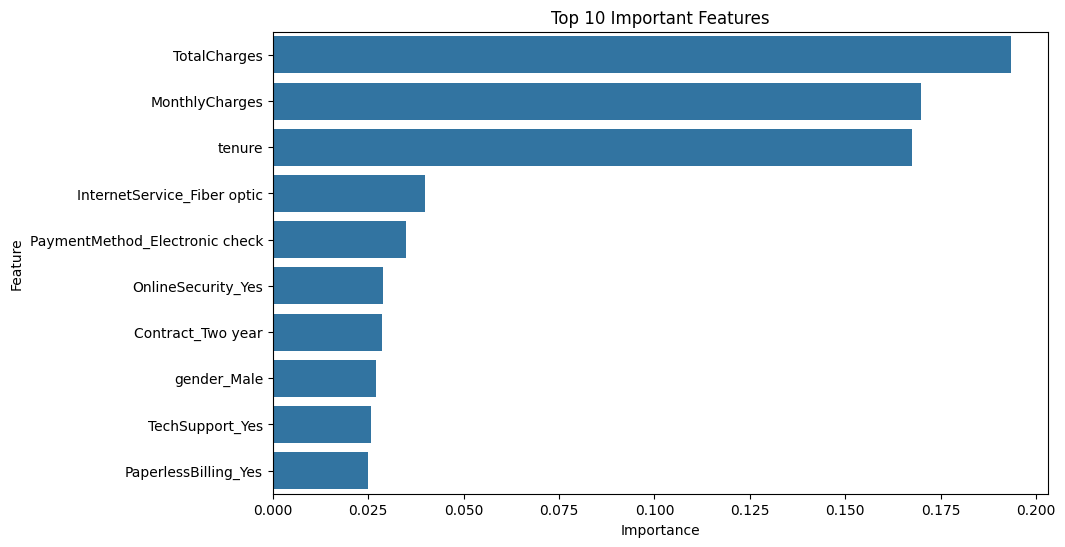

In [178]:
plt.figure(figsize=(10,6))
# Feature Importance Graph
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

### ROC Curve 
1. Model churn aur non-churn customers ko kitni achhi tarah alag kar raha hai

In [ ]:
# For the ROC curve, we need probability (predict_proba), not a prediction (predict).

y_prob = best_dt.predict_proba(X_test)[:, 1]


In [180]:
y_prob

array([0.03448276, 0.0239726 , 0.74496644, ..., 0.09780439, 0.29411765,
       0.00747198], shape=(1407,))

In [ ]:
# Preparing raw data 
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [182]:
fpr

array([0.        , 0.        , 0.00290416, 0.02904163, 0.03775411,
       0.06389158, 0.10454985, 0.15779284, 0.16650532, 0.18877057,
       0.24782188, 0.26137464, 0.27395934, 0.31558567, 0.32042594,
       0.32526621, 0.3446273 , 0.34753146, 0.39883833, 0.42594385,
       0.45111326, 0.56340755, 0.57889642, 0.64859632, 0.6892546 ,
       0.70764763, 0.71732817, 0.78412391, 0.79186834, 0.99806389,
       1.        ])

In [183]:
tpr

array([0.        , 0.02673797, 0.11497326, 0.21925134, 0.2513369 ,
       0.37967914, 0.49197861, 0.59090909, 0.59893048, 0.62834225,
       0.70588235, 0.71925134, 0.74064171, 0.76737968, 0.76737968,
       0.78074866, 0.80481283, 0.80481283, 0.85828877, 0.87165775,
       0.89037433, 0.92780749, 0.93582888, 0.96524064, 0.96791444,
       0.97593583, 0.98128342, 0.98930481, 0.98930481, 0.9973262 ,
       1.        ])

In [184]:
thresholds

array([       inf, 1.        , 0.84713376, 0.74496644, 0.57142857,
       0.56962025, 0.55813953, 0.51804124, 0.39622642, 0.3537415 ,
       0.31402439, 0.29411765, 0.28571429, 0.26857143, 0.26666667,
       0.26470588, 0.24      , 0.21428571, 0.17857143, 0.13380282,
       0.1221374 , 0.09780439, 0.09565217, 0.0753012 , 0.07296137,
       0.06410256, 0.03448276, 0.0239726 , 0.02      , 0.00747198,
       0.        ])

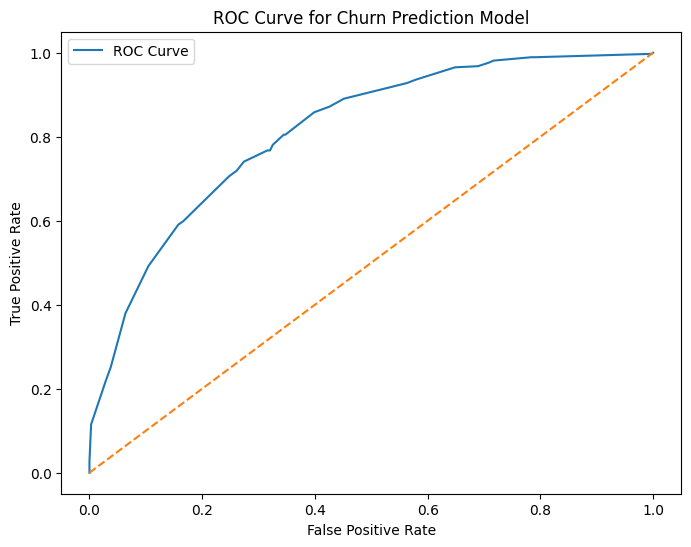

In [185]:
# ROC Curve Plot 

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,  label="ROC Curve")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Churn Prediction Model")

plt.legend()
plt.show()

In [ ]:
# AUC Score  

from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.8129662319913445


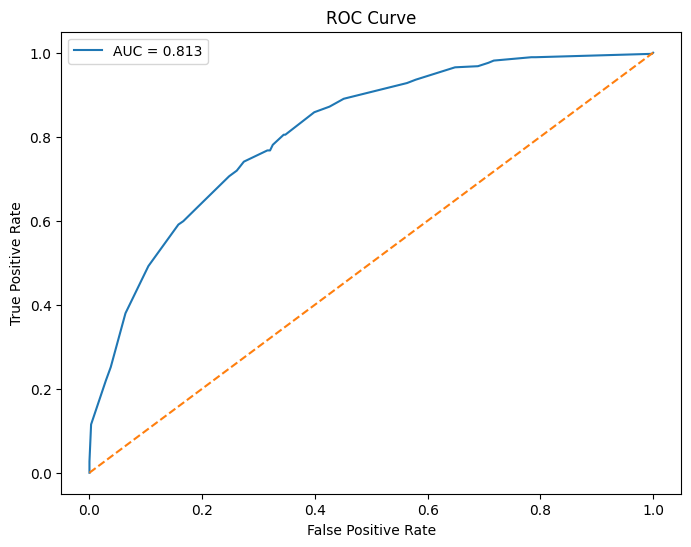

In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

###  Probability Nikaalo 

In [188]:
y_prob = best_dt.predict_proba(X_test)[:, 1]   

In [189]:
# AUC Score Calculate Karo
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.8129662319913445


In [190]:
roc_auc_score(y_test, y_prob)

0.8129662319913445

## Task 6: Business Recommendations
1. Description: Based on the analysis and predictive
models, provide actionable recommendations to
the business. Suggest specific marketing
strategies, retention offers, or customer
engagement tactics. Estimate the potential
impact of these recommendations on revenue
and churn rate.

2. skill :
Business acumen ,
Data-driven decision-making,
Strategic thinking,
Impact estimation ,
Communication skills

In [191]:
churn_prob = best_dt.predict_proba(X_test)[:, 1]

high_risk = X_test.copy()

high_risk["Churn_Probability"] = churn_prob

high_risk = high_risk.sort_values(
    by="Churn_Probability",
    ascending=False
)

high_risk.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Probability
4837,0,1,69.80,69.80,0,True,True,True,False,False,...,False,False,False,False,False,True,False,True,False,1.0
6488,0,1,69.50,69.50,0,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1.0
5872,0,1,69.65,69.65,0,False,True,True,False,False,...,False,False,False,False,False,True,False,True,False,1.0
6495,0,1,69.65,69.65,1,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1.0
1731,1,1,69.60,69.60,0,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1.0
6924,0,1,69.35,69.35,1,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1.0
4228,0,1,68.50,68.50,1,True,True,True,False,False,...,False,False,False,False,False,True,False,True,False,1.0
1325,1,1,69.25,69.25,0,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1.0
5454,1,1,69.55,69.55,0,True,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1.0
6933,0,1,69.60,69.60,1,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1.0


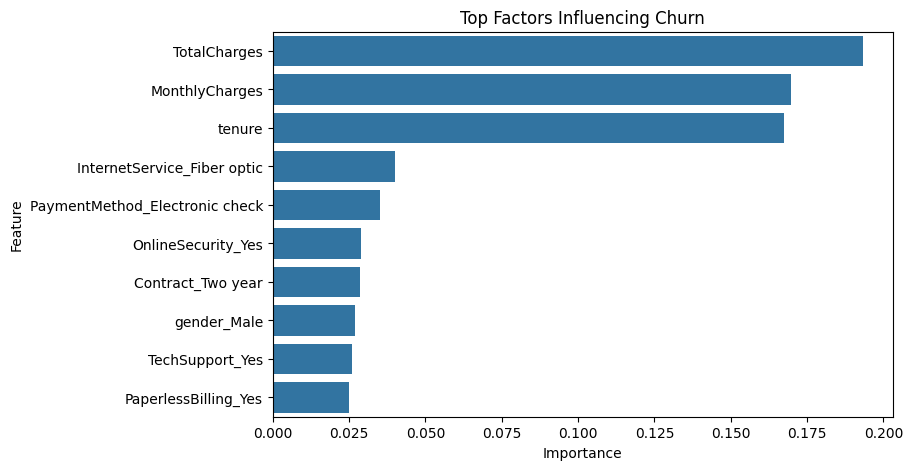

In [192]:
top_features = importance_df.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top Factors Influencing Churn")
plt.show()

In [193]:
import pickle

In [195]:
import pickle

with open("churn_model.pkl", "wb") as file:
    pickle.dump(best_dt, file)

print("Model Saved Successfully")

Model Saved Successfully


In [196]:
print(best_dt)

DecisionTreeClassifier(max_depth=5, random_state=42)


In [197]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [199]:
print(X.shape)

(7032, 30)


In [202]:
lr.fit(X_train_scaled, y_train)

print(best_dt)

print(X.shape)

print(X.columns)

DecisionTreeClassifier(max_depth=5, random_state=42)
(7032, 30)
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [203]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Group,Contract_Type,Payment_Method,Tenure_Segment,Charge_Segment
0,0,1,29.85,29.85,0,0,True,False,False,True,...,False,True,False,True,False,0-12,Month-to-month,Electronic check,New Customer,Low Value
1,0,34,56.95,1889.50,0,1,False,False,True,False,...,False,False,False,False,True,25-48,One year,Mailed check,Loyal Customer,Medium Value
2,0,2,53.85,108.15,1,1,False,False,True,False,...,False,True,False,False,True,0-12,Month-to-month,Mailed check,New Customer,Medium Value
3,0,45,42.30,1840.75,0,1,False,False,False,True,...,False,False,False,False,False,25-48,One year,Bank transfer (automatic),Loyal Customer,Medium Value
4,0,2,70.70,151.65,1,0,False,False,True,False,...,False,True,False,True,False,0-12,Month-to-month,Electronic check,New Customer,High Value
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,1,True,True,True,False,...,False,True,False,False,True,13-24,One year,Mailed check,Regular Customer,High Value
7039,0,72,103.20,7362.90,0,0,True,True,True,False,...,False,True,True,False,False,49-72,One year,Credit card (automatic),Long-Term Customer,High Value
7040,0,11,29.60,346.45,0,0,True,True,False,True,...,False,True,False,True,False,0-12,Month-to-month,Electronic check,New Customer,Low Value
7041,1,4,74.40,306.60,1,1,True,False,True,False,...,False,True,False,False,True,0-12,Month-to-month,Mailed check,New Customer,High Value


In [204]:
print(X.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [209]:
print(X.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [205]:
X = df.drop(
    columns=[
        "Churn",
        "Contract_Type",
        "Payment_Method",
        "Tenure_Group",
        "Tenure_Segment",
        "Charge_Segment"
    ],
    errors="ignore"
)

In [206]:
print(X.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [207]:
import pickle

with open("churn_model.pkl", "wb") as f:
    pickle.dump(best_dt, f)

print("Model Saved")

Model Saved


In [208]:
import os

print(os.listdir())

['churn_model.pkl', 'customer_churn_analysis.ipynb', 'hello.ipynb', 'Telco_Customer_Churn_Dataset  (3).csv']


In [210]:
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Partner_Yes",
    "Dependents_Yes",
    "Contract_One year",
    "Contract_Two year",
    "PaymentMethod_Credit card (automatic)",
    "PaymentMethod_Electronic check",
    "PaymentMethod_Mailed check"
]

X = df[features]
y = df["Churn"]

In [211]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [212]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [213]:
import pickle

with open("churn_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model Saved")

Model Saved


In [214]:
model.score(X_test, y_test)

0.7668798862828714